<a href="https://colab.research.google.com/github/edemile/ML-Final-project/blob/main/kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# kNN Implementation

In [55]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [56]:
def compute_metrics(y_true, y_pred, y_probs, dataset_name):
    """ Computes and prints classification metrics.

    Args:
        y_true (numpy.ndarray): True labels
        y_pred (numpy.ndarray): Predicted class labels
        y_probs (numpy.ndarray): Predicted probabilities for positive class
        dataset_name (str): Name of dataset (e.g., "Training", "Testing")

    Returns:
        tuple: (accuracy, f1, auc)
    """

    # Compute standard classification metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)

    # Print results
    print(f"\n{dataset_name} Metrics")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {auc:.4f}")

    return accuracy, f1, auc

In [57]:
def plot_roc(y_true, y_probs, auc_score):
    """ Plots ROC curve.

    Args:
        y_true (numpy.ndarray): True labels
        y_probs (numpy.ndarray): Predicted probabilities
        auc_score (float): AUC value

    Returns:
        None
    """

    # Compute false positive rate and true positive rate
    fpr, tpr, _ = roc_curve(y_true, y_probs)

    # Plot ROC curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('kNN - ROC Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

In [58]:
def plot_confusion(y_true, y_pred):
    """Plots confusion matrix.

    Args:
        y_true (numpy.ndarray): True labels
        y_pred (numpy.ndarray): Predicted labels

    Returns:
        None
    """

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    plt.title('kNN - Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [59]:
# Import Google Drive to upload data
from google.colab import drive
drive.mount('/content/drive')

# Read in data from file path
file_id = '1K9R2xpxjPZYypVshY3fKUC5-VHWPgP0KxQivMES2zsQ'
file_path = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid=86751017"

df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
# Define feature columns
feature_cols = [
    'High blood pressure',
    'High cholesterol',
    'Taking medicine for high cholesterol',
    'Taking medicine to control high blood pressure'
]

# Separate features and target
X = df[feature_cols]
y = df['high_risk']

# Impute missing values using mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize features for kNN distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 599
Testing set size: 150


In [45]:
# Test different k values using cross-validation
k_values = range(1, 31)
cv_f1_scores = []

for k in k_values:
    # Initialize kNN model
    model = KNeighborsClassifier(n_neighbors=k)

    # Perform 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

    # Store mean F1 score
    cv_f1_scores.append(scores.mean())

In [46]:
# Select best k based on highest F1 score
best_k = k_values[np.argmax(cv_f1_scores)]
print(f"\nOptimal k: {best_k}")


Optimal k: 21


In [47]:
# Train final model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=21)

In [48]:
# Generate predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Get predicted probabilities for ROC-AUC
y_train_probs = model.predict_proba(X_train)[:, 1]
y_test_probs = model.predict_proba(X_test)[:, 1]

In [49]:
# Compute metrics for training set
compute_metrics(y_train, y_train_pred, y_train_probs, "Training")

# Compute metrics for testing set
_, _, test_auc = compute_metrics(y_test, y_test_pred, y_test_probs, "Testing")


Training Metrics
Accuracy: 0.7913
Precision: 0.8024
Recall: 0.8242
F1 Score: 0.8132
ROC-AUC: 0.8830

Testing Metrics
Accuracy: 0.7533
Precision: 0.7556
Recall: 0.8193
F1 Score: 0.7861
ROC-AUC: 0.8362


In [50]:
# Perform cross-validation on full dataset
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')
print(f"\n5-Fold Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


5-Fold Cross-Validation F1 Scores: [0.85542169 0.87209302 0.74698795 0.75739645 0.76363636]
Mean CV F1: 0.7991 (+/- 0.0533)


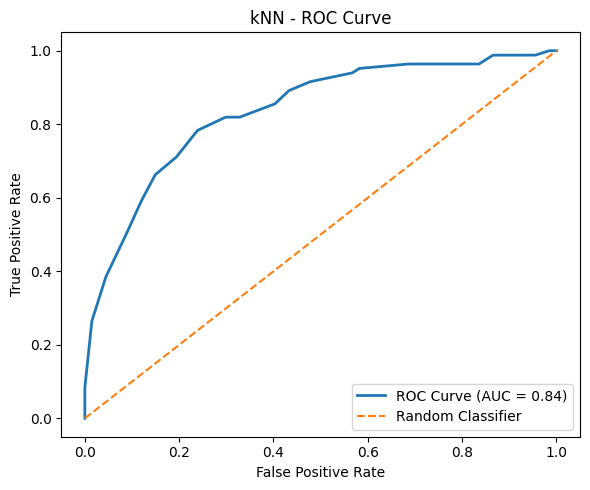

In [51]:
# Plot ROC curve
plot_roc(y_test, y_test_probs, test_auc)

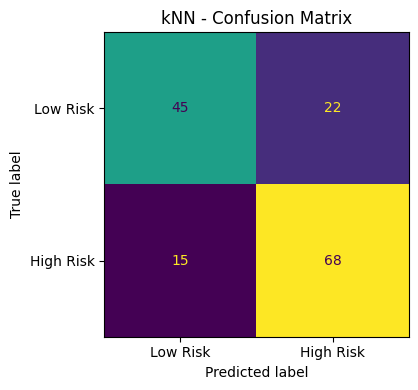

In [52]:
# Plot confusion matrix
plot_confusion(y_test, y_test_pred)

In [53]:
# Store F1 scores for training and testing sets across different k values
train_f1_scores = []
test_f1_scores = []

# Evaluate model performance for each value of k
for k in k_values:
    # Initialize kNN model with current number of neighbors
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    # Generate training predictions
    y_train_pred = model.predict(X_train)

    # Compute training F1 score
    train_f1 = f1_score(y_train, y_train_pred)
    train_f1_scores.append(train_f1)

    # Generate testing predictions
    y_test_pred = model.predict(X_test)

    # Compute testing F1 score
    test_f1 = f1_score(y_test, y_test_pred)
    test_f1_scores.append(test_f1)

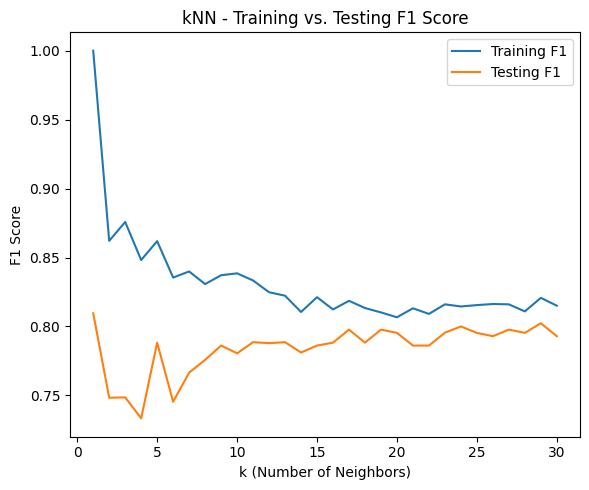

In [54]:
# Plot k vs. F1 score
plt.figure(figsize=(6, 5))

plt.plot(k_values, train_f1_scores, label='Training F1')
plt.plot(k_values, test_f1_scores, label='Testing F1')

plt.xlabel('k (Number of Neighbors)')
plt.ylabel('F1 Score')
plt.title('kNN - Training vs. Testing F1 Score')
plt.legend()
plt.tight_layout()
plt.show()